In [ ]:
# ============================================================
# 第五步：模拟 Pipeline 全流程 — 预处理 + 检测 + 分割 + 后处理
# ============================================================
import sys
sys.path.insert(0, ".")

from app.core.preprocess import PreprocessParams, preprocess_gray
from app.core.postprocess import postprocess_mask
from app.core.segment import SegmentParams, segment_roi

# Pipeline 默认参数（与 routes.py / pipeline.py 一致）
PP = PreprocessParams(
    median_ksize=5,
    use_bilateral=True,
    bilateral_d=7,
    bilateral_sigma_color=75.0,
    bilateral_sigma_space=50.0,
    clahe_clip=3.0,
    clahe_tile=8,
    use_tophat=False,    # 已修复：关闭 tophat
    use_blackhat=False,
)

# 分割参数：dual = Triangle vs Otsu 自动选优
SP = SegmentParams(method="dual", threshold_kind="triangle", morph_kernel=3)
# raw 灰度用 Triangle（第四步已验证最优）
SP_RAW = SegmentParams(method="otsu_roi", threshold_kind="triangle", morph_kernel=3)

pipeline_records = []

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    gray_raw = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask_gt = cv2.imread(str(find_mask(img_path)), cv2.IMREAD_GRAYSCALE)

    # ---- Pipeline 路径 ----
    t0 = time.perf_counter()
    enhanced = preprocess_gray(img, PP)
    mask, _ = segment_roi(enhanced, SP)
    mask = postprocess_mask(mask, min_post_area=30)
    elapsed = (time.perf_counter() - t0) * 1000
    d_pipe, iou_pipe = dice_iou(mask, mask_gt)

    # ---- Notebook 路径 (raw灰度 + Triangle) ----
    t0_raw = time.perf_counter()
    mask_raw, _ = segment_roi(gray_raw, SP_RAW)
    elapsed_raw = (time.perf_counter() - t0_raw) * 1000
    d_raw, iou_raw = dice_iou(mask_raw, mask_gt)

    pipeline_records.append({
        "Image": img_path.stem,
        "Dice_pipeline": d_pipe, "IoU_pipeline": iou_pipe, "Time_pipeline": elapsed,
        "Dice_raw": d_raw, "IoU_raw": iou_raw, "Time_raw": elapsed_raw,
    })

df_pipe = pd.DataFrame(pipeline_records)

# ---- 汇总表格 ----
print("=" * 78)
print("Pipeline (CLAHE+bilateral+dual+后处理) vs Notebook (raw灰度+Triangle)")
print("=" * 78)
print(f"{'Image':<16} {'Pipe Dice':>10} {'Raw Dice':>10} {'Diff':>8} {'Pipe ms':>8} {'Raw ms':>8}")
print("-" * 78)
for _, row in df_pipe.iterrows():
    diff = row["Dice_pipeline"] - row["Dice_raw"]
    marker = " +" if diff > 0 else " -" if diff < 0 else " ="
    print(f"{row['Image']:<16} {row['Dice_pipeline']:10.4f} {row['Dice_raw']:10.4f} {diff:+.4f}{marker} {row['Time_pipeline']:8.1f} {row['Time_raw']:8.1f}")

print("-" * 78)
avg_pipe = df_pipe["Dice_pipeline"].mean()
avg_raw = df_pipe["Dice_raw"].mean()
print(f"{'AVERAGE':<16} {avg_pipe:10.4f} {avg_raw:10.4f} {avg_pipe-avg_raw:+.4f}")

wins = (df_pipe["Dice_pipeline"] > df_pipe["Dice_raw"]).sum()
losses = (df_pipe["Dice_pipeline"] < df_pipe["Dice_raw"]).sum()
ties = (df_pipe["Dice_pipeline"] == df_pipe["Dice_raw"]).sum()
print(f"\nPipeline wins: {wins}/15, loses: {losses}/15, ties: {ties}/15")

# ---- 可视化：第一张图对比 ----
img0 = cv2.imread(str(image_paths[0]))
gray_raw0 = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
enhanced0 = preprocess_gray(img0, PP)

mask_pipe0, _ = segment_roi(enhanced0, SP)
mask_pipe0 = postprocess_mask(mask_pipe0, min_post_area=30)
mask_raw0, _ = segment_roi(gray_raw0, SP_RAW)
mask_gt0 = cv2.imread(str(find_mask(image_paths[0])), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(cv2.cvtColor(img0, cv2.COLOR_BGR2RGB))
axes[0].set_title("原图", fontsize=12); axes[0].axis("off")
axes[1].imshow(enhanced0, cmap="gray")
axes[1].set_title("Pipeline 预处理\n(CLAHE+bilateral 无tophat)", fontsize=10); axes[1].axis("off")

d, i = dice_iou(mask_raw0, mask_gt0)
axes[2].imshow(cv2.cvtColor(create_overlay(img0, mask_raw0), cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Notebook: raw灰度+Triangle\nDice={d:.4f} IoU={i:.4f}", fontsize=10); axes[2].axis("off")

d, i = dice_iou(mask_pipe0, mask_gt0)
axes[3].imshow(cv2.cvtColor(create_overlay(img0, mask_pipe0), cv2.COLOR_BGR2RGB))
axes[3].set_title(f"Pipeline: CLAHE+dual+后处理\nDice={d:.4f} IoU={i:.4f}", fontsize=10); axes[3].axis("off")

plt.suptitle("Pipeline 全流程 vs Notebook — 第一张图对比", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- 差值分布 ----
diffs = df_pipe["Dice_pipeline"] - df_pipe["Dice_raw"]
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#22c55e" if d > 0 else "#ef4444" if d < 0 else "#94a3b8" for d in diffs]
ax.bar(range(len(diffs)), diffs, color=colors)
ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xticks(range(len(diffs)))
ax.set_xticklabels(df_pipe["Image"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Dice Difference (Pipeline - Raw)")
ax.set_title(f"Dice 差值分布 (平均 {diffs.mean():+.4f}, 胜{wins} 负{losses} 平{ties})", fontsize=12)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 分割算法性能对比测试

用 data/ 里的 ISIC 皮肤病灶图像 + Ground Truth mask，对比 4 种算法的效果。

| 算法 | 原理 | 适用场景 |
|------|------|------|
| **Otsu** | 全局阈值使类间方差最大 + 形态学 | 前景/背景对比度高 |
| **Triangle** | 灰度直方图三角形法找阈值 | 单峰直方图 |
| **Region Growing** | 从种子点 floodFill 扩展 | 边界模糊但有内部一致性 |
| **Watershed** | 距离变换 + 分水岭 | 粘连目标、复杂形状 |

**测试维度**：视觉效果 / Dice & IoU / 耗时 / 参数敏感度

In [2]:
# ============================================================
# Cell 1: 导入所有依赖
# ============================================================
from __future__ import annotations

import time
from pathlib import Path
from typing import Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from app.core.segment import (
    SegmentParams,
    segment_otsu_triangle,
    segment_region_grow,
    segment_watershed,
    segment_roi,
    score_segmentation,
)

plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "SimHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print("导入完成")

导入完成


---

## 第一步：加载 data/ 里的真实图像 + Ground Truth

15 张 ISIC 病灶图，每张都有对应的 `_segmentation.png` mask。

图像数量: 15
Mask 数量: 15


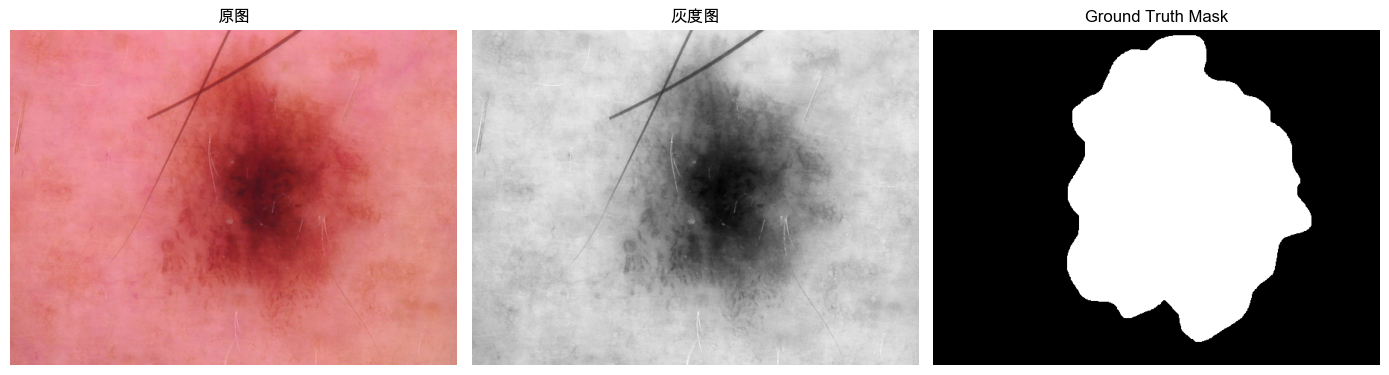

尺寸: (450, 600), 灰度范围: [34, 194], Mask唯一值: [  0 255]


In [3]:
# ============================================================
# 第一步：加载真实数据
# ============================================================

DATA_DIR = Path("data")
IMAGE_DIR = DATA_DIR / "image"
MASK_DIR = DATA_DIR / "mask"

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))
mask_paths = sorted(MASK_DIR.glob("*_segmentation.png"))

print(f"图像数量: {len(image_paths)}")
print(f"Mask 数量: {len(mask_paths)}")


def find_mask(img_path: Path) -> Path:
    stem = img_path.stem  # e.g. ISIC_0024306
    mp = MASK_DIR / f"{stem}_segmentation.png"
    return mp if mp.exists() else None


# 加载第一张预览
img = cv2.imread(str(image_paths[0]))
mask_gt = cv2.imread(str(find_mask(image_paths[0])), cv2.IMREAD_GRAYSCALE)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("原图"); axes[0].axis("off")
axes[1].imshow(gray, cmap="gray")
axes[1].set_title("灰度图"); axes[1].axis("off")
axes[2].imshow(mask_gt, cmap="gray")
axes[2].set_title("Ground Truth Mask"); axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"尺寸: {img.shape[:2]}, 灰度范围: [{gray.min()}, {gray.max()}], Mask唯一值: {np.unique(mask_gt)}")

---

## 第二步：单张图像 — 4 种算法对比

红色 = 预测 mask 叠加到原图，标注 Dice / IoU / 耗时。

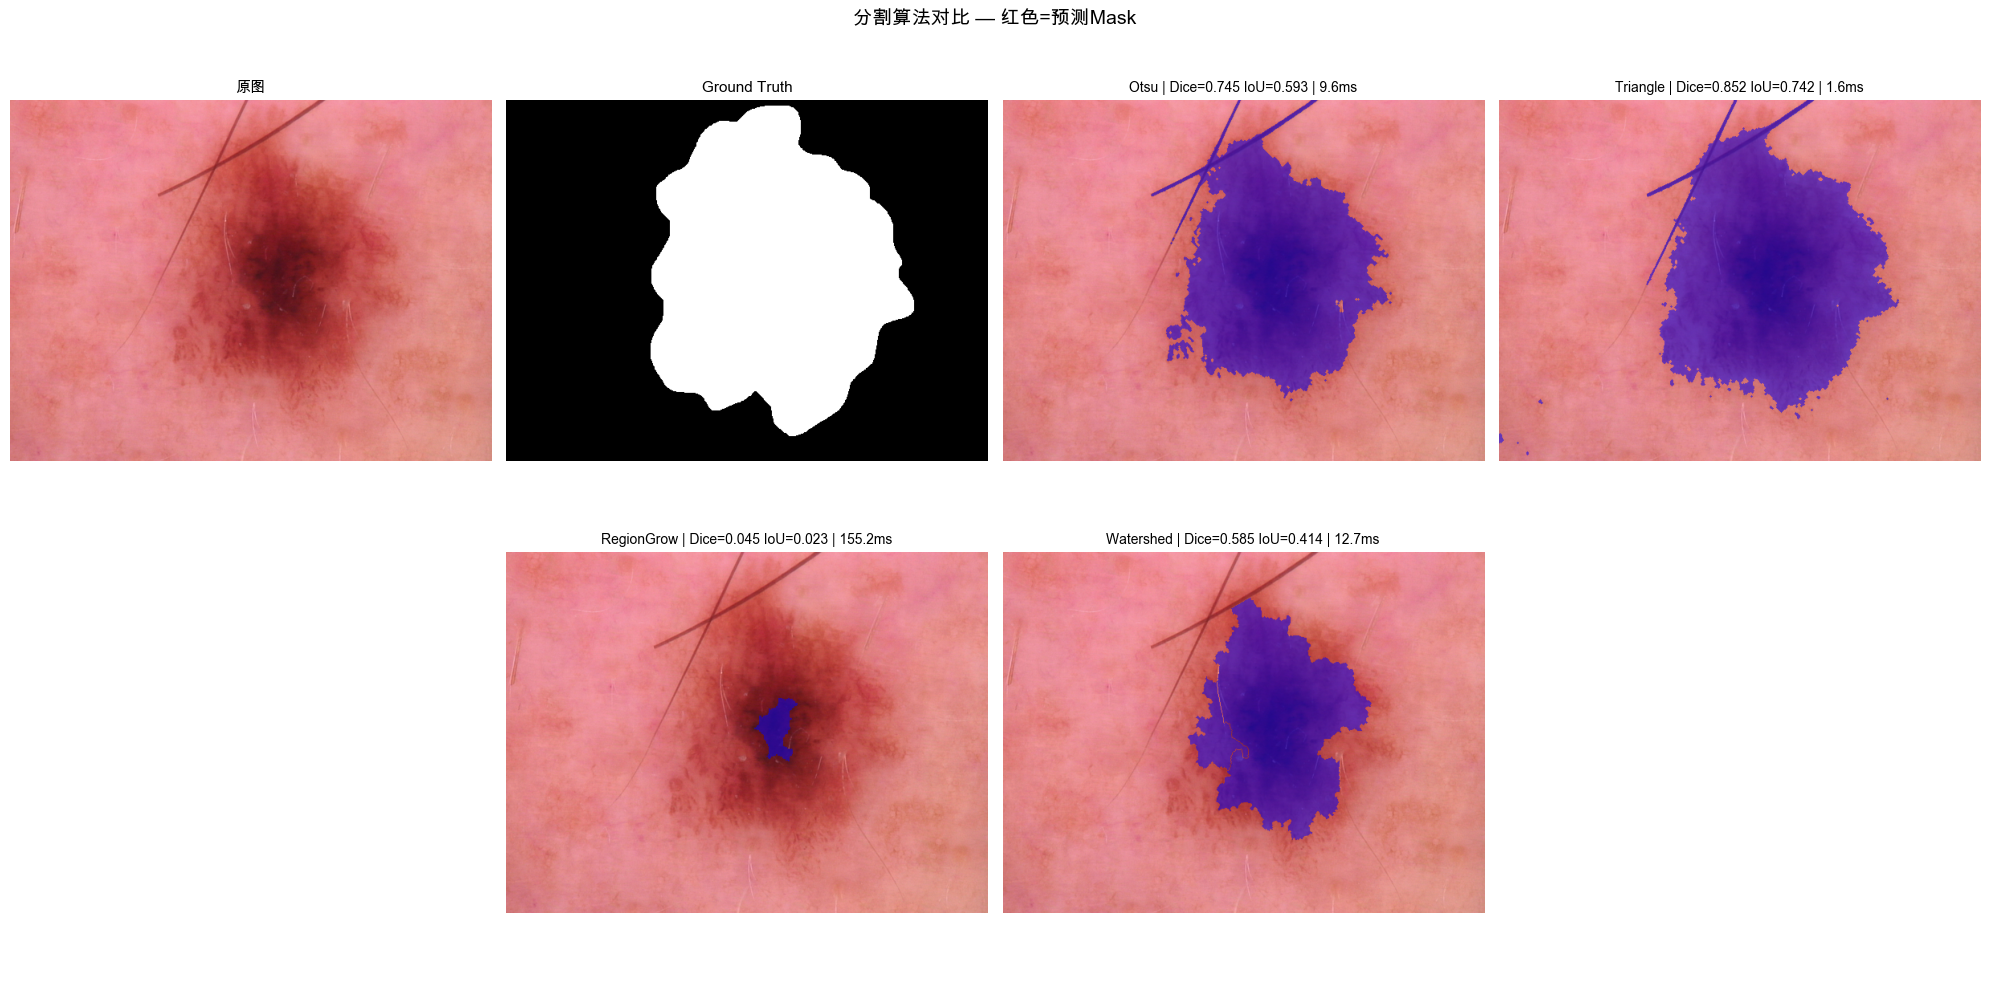


Method             Dice      IoU   Time(ms)
-------------------------------------------------------
Otsu             0.7447   0.5932       9.6
Triangle         0.8520   0.7421       1.6
RegionGrow       0.0453   0.0232     155.2
Watershed        0.5853   0.4137      12.7
-------------------------------------------------------


In [4]:
# ============================================================
# 第二步：单张图像 — 4 种算法横向对比
# ============================================================

def dice_iou(pred: np.ndarray, gt: np.ndarray) -> Tuple[float, float]:
    pred_bin = (pred > 127).astype(np.uint8)
    gt_bin = (gt > 127).astype(np.uint8)
    inter = np.sum(pred_bin & gt_bin)
    total = np.sum(pred_bin) + np.sum(gt_bin)
    dice = 2 * inter / total if total > 0 else 0.0
    iou = inter / (total - inter) if (total - inter) > 0 else 0.0
    return dice, iou


def create_overlay(img_bgr, mask, color=(255, 0, 0), alpha=0.5):
    overlay = img_bgr.copy()
    overlay[mask > 127] = (
        overlay[mask > 127] * (1 - alpha) + np.array(color) * alpha
    ).astype(np.uint8)
    return overlay


# ---- 选第一张图 ----
img = cv2.imread(str(image_paths[0]))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask_gt = cv2.imread(str(find_mask(image_paths[0])), cv2.IMREAD_GRAYSCALE)

results = {}
method_names = ["Otsu", "Triangle", "RegionGrow", "Watershed"]

# 1. Otsu
t0 = time.perf_counter()
p = SegmentParams(method="otsu_roi", threshold_kind="otsu", morph_kernel=3)
mask, _ = segment_roi(gray, p)
d, iou = dice_iou(mask, mask_gt)
results["Otsu"] = {"mask": mask, "time_ms": (time.perf_counter()-t0)*1000, "dice": d, "iou": iou}

# 2. Triangle
t0 = time.perf_counter()
p = SegmentParams(method="otsu_roi", threshold_kind="triangle", morph_kernel=3)
mask, _ = segment_roi(gray, p)
d, iou = dice_iou(mask, mask_gt)
results["Triangle"] = {"mask": mask, "time_ms": (time.perf_counter()-t0)*1000, "dice": d, "iou": iou}

# 3. Region Growing
t0 = time.perf_counter()
p = SegmentParams(method="region_grow", grow_T=15, seed_strategy="dark")
mask, _ = segment_roi(gray, p)
d, iou = dice_iou(mask, mask_gt)
results["RegionGrow"] = {"mask": mask, "time_ms": (time.perf_counter()-t0)*1000, "dice": d, "iou": iou}

# 4. Watershed
t0 = time.perf_counter()
p = SegmentParams(method="watershed", morph_kernel=3)
mask, warns = segment_watershed(gray, p)
d, iou = dice_iou(mask, mask_gt)
results["Watershed"] = {"mask": mask, "time_ms": (time.perf_counter()-t0)*1000, "dice": d, "iou": iou}
if warns:
    print(f"Watershed 警告: {warns}")

# ---- 可视化 2x4 ----
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("分割算法对比 — 红色=预测Mask", fontsize=14, fontweight="bold")

axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("原图", fontsize=11); axes[0, 0].axis("off")
axes[0, 1].imshow(mask_gt, cmap="gray")
axes[0, 1].set_title("Ground Truth", fontsize=11); axes[0, 1].axis("off")

for idx, name in enumerate(["Otsu", "Triangle"]):
    r = results[name]
    ax = axes[0, 2 + idx]
    ax.imshow(cv2.cvtColor(create_overlay(img, r["mask"]), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} | Dice={r['dice']:.3f} IoU={r['iou']:.3f} | {r['time_ms']:.1f}ms", fontsize=10)
    ax.axis("off")

axes[1, 0].axis("off")
for idx, name in enumerate(["RegionGrow", "Watershed"]):
    r = results[name]
    ax = axes[1, 1 + idx]
    ax.imshow(cv2.cvtColor(create_overlay(img, r["mask"]), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name} | Dice={r['dice']:.3f} IoU={r['iou']:.3f} | {r['time_ms']:.1f}ms", fontsize=10)
    ax.axis("off")
axes[1, 3].axis("off")

plt.tight_layout()
plt.show()

# 控制台汇总
print("\n" + "=" * 55)
print(f"{'Method':<14} {'Dice':>8} {'IoU':>8} {'Time(ms)':>10}")
print("-" * 55)
for name in method_names:
    r = results[name]
    print(f"{name:<14} {r['dice']:8.4f} {r['iou']:8.4f} {r['time_ms']:9.1f}")
print("-" * 55)

---

## 第三步：参数敏感度分析

对 **Region Growing** 扫描 `grow_T`（5~50），看 Dice 曲线，找最佳参数。

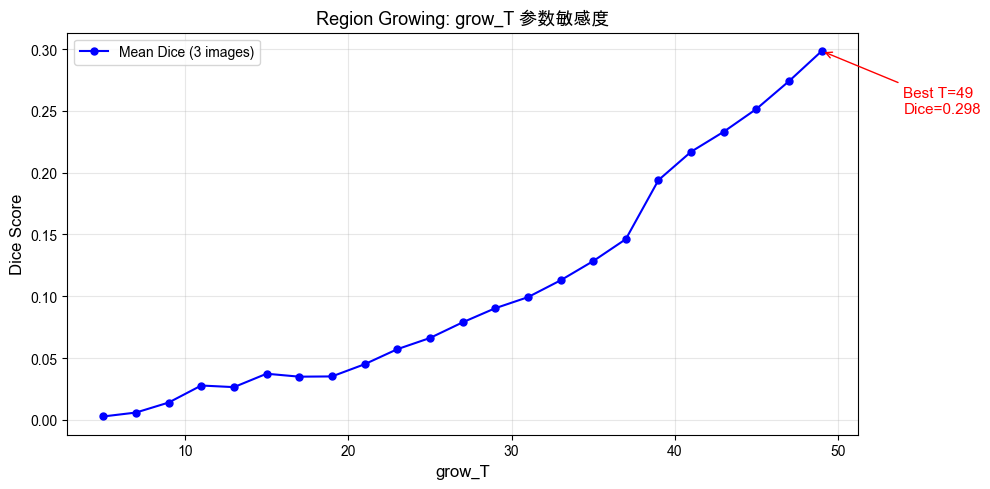

最佳 grow_T = 49, Dice = 0.2984

Top-5 参数:
  1. T= 49  Dice=0.2984
  2. T= 47  Dice=0.2741
  3. T= 45  Dice=0.2516
  4. T= 43  Dice=0.2331
  5. T= 41  Dice=0.2169


In [10]:
# ============================================================
# 第三步：参数扫描 — grow_T 对 Dice 的影响
# ============================================================

test_indices = [0, 1, 2]  # 用前3张图取平均
T_values = list(range(5, 51, 2))  # 5, 7, ..., 49
all_dice = {t: [] for t in T_values}

for idx in test_indices:
    img = cv2.imread(str(image_paths[idx]))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask_gt = cv2.imread(str(find_mask(image_paths[idx])), cv2.IMREAD_GRAYSCALE)
    
    for T in T_values:
        p = SegmentParams(method="region_grow", grow_T=T, seed_strategy="dark")
        mask, _ = segment_roi(gray, p)
        d, _ = dice_iou(mask, mask_gt)
        all_dice[T].append(d)

mean_dice = [np.mean(all_dice[t]) for t in T_values]
best_idx = np.argmax(mean_dice)
best_T = T_values[best_idx]

# ---- 画曲线 ----
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(T_values, mean_dice, "b-o", markersize=5, label="Mean Dice (3 images)")
ax.annotate(f"Best T={best_T}\nDice={mean_dice[best_idx]:.3f}",
            xy=(best_T, mean_dice[best_idx]),
            xytext=(best_T + 5, mean_dice[best_idx] - 0.05),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=11, color="red", fontweight="bold")
ax.set_xlabel("grow_T", fontsize=12)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_title("Region Growing: grow_T 参数敏感度", fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"最佳 grow_T = {best_T}, Dice = {mean_dice[best_idx]:.4f}")
print("\nTop-5 参数:")
for rank, (t, d) in enumerate(sorted(zip(T_values, mean_dice), key=lambda x: x[1], reverse=True)[:5], 1):
    print(f"  {rank}. T={t:3d}  Dice={d:.4f}")

---

## 第四步：批量评估 — 全部 15 张图

每张图跑 4 种算法，统计平均 Dice / IoU / 耗时，箱线图看稳定性。

各算法平均性能 (15张图)
            Dice_mean  Dice_std  IoU_mean  IoU_std  Time_mean
Method                                                       
Otsu           0.7604    0.1298    0.6294   0.1647     0.6284
RegionGrow     0.0586    0.1214    0.0346   0.0744    14.7534
Triangle       0.7856    0.1615    0.6728   0.2094     0.4329
Watershed      0.6291    0.1653    0.4788   0.1773     6.3866



/var/folders/b3/hzp_vvrs79q4hp8f465nwfz40000gp/T/ipykernel_67793/1573712576.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([all_dice_data[m] for m in algos], labels=algos)
/var/folders/b3/hzp_vvrs79q4hp8f465nwfz40000gp/T/ipykernel_67793/1573712576.py:57: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([iou_data[m] for m in algos], labels=algos)
/var/folders/b3/hzp_vvrs79q4hp8f465nwfz40000gp/T/ipykernel_67793/1573712576.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot([time_data[m] for m in algos], labels=algos)


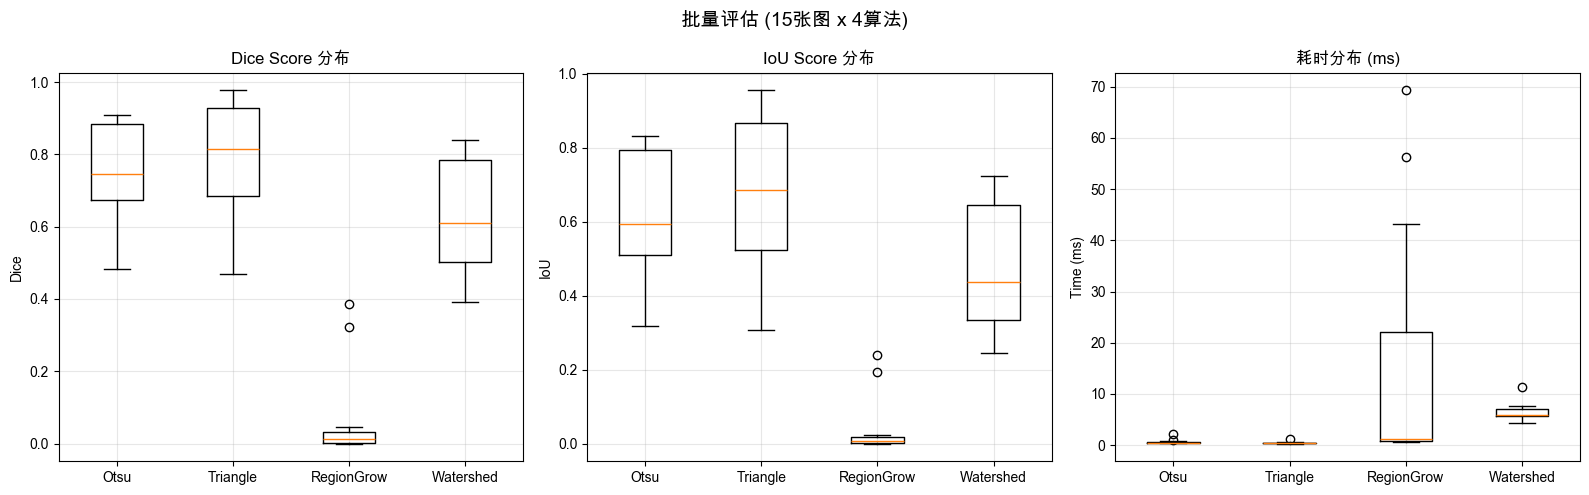


每张图各算法 Dice 对比:
Method          Otsu  RegionGrow  Triangle  Watershed
Image                                                
ISIC_0024306  0.7447      0.0453    0.8520     0.5853
ISIC_0024307  0.6107      0.0405    0.6366     0.4179
ISIC_0024308  0.8898      0.0261    0.9395     0.7385
ISIC_0024309  0.7330      0.0153    0.8124     0.5438
ISIC_0024310  0.7235      0.0152    0.7628     0.4756
ISIC_0024311  0.8784      0.0046    0.9185     0.7040
ISIC_0024312  0.6905      0.0018    0.4686     0.3925
ISIC_0024313  0.6288      0.0000    0.7129     0.5274
ISIC_0024314  0.4838      0.0000    0.5037     0.3941
ISIC_0024315  0.6588      0.3848    0.6588     0.6088
ISIC_0024316  0.9015      0.0012    0.9467     0.7750
ISIC_0024317  0.9086      0.3237    0.9767     0.7926
ISIC_0024318  0.7987      0.0131    0.8135     0.8385
ISIC_0024319  0.8964      0.0004    0.9582     0.8219
ISIC_0024320  0.8586      0.0077    0.8237     0.8208


In [6]:
# ============================================================
# 第四步：全部 15 张图批量评估
# ============================================================

records = []
all_dice_data = {"Otsu": [], "Triangle": [], "RegionGrow": [], "Watershed": []}

for img_path in image_paths:
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask_gt = cv2.imread(str(find_mask(img_path)), cv2.IMREAD_GRAYSCALE)

    configs = [
        ("Otsu",       SegmentParams(method="otsu_roi", threshold_kind="otsu", morph_kernel=3)),
        ("Triangle",   SegmentParams(method="otsu_roi", threshold_kind="triangle", morph_kernel=3)),
        ("RegionGrow", SegmentParams(method="region_grow", grow_T=15, seed_strategy="dark")),
        ("Watershed",  SegmentParams(method="watershed", morph_kernel=3)),
    ]

    for name, params in configs:
        t0 = time.perf_counter()
        if name == "Watershed":
            mask, _ = segment_watershed(gray, params)
        else:
            mask, _ = segment_roi(gray, params)
        elapsed = (time.perf_counter() - t0) * 1000
        d, iou = dice_iou(mask, mask_gt)
        records.append({
            "Image": img_path.stem, "Method": name,
            "Dice": d, "IoU": iou, "Time_ms": elapsed,
        })
        all_dice_data[name].append(d)

df = pd.DataFrame(records)

# ---- 汇总统计 ----
print("=" * 70)
print("各算法平均性能 (15张图)")
print("=" * 70)
summary = df.groupby("Method").agg(
    Dice_mean=("Dice", "mean"), Dice_std=("Dice", "std"),
    IoU_mean=("IoU", "mean"),  IoU_std=("IoU", "std"),
    Time_mean=("Time_ms", "mean"),
).round(4)
print(summary.to_string())
print()

# ---- 箱线图 ----
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
algos = ["Otsu", "Triangle", "RegionGrow", "Watershed"]

axes[0].boxplot([all_dice_data[m] for m in algos], labels=algos)
axes[0].set_title("Dice Score 分布", fontsize=12)
axes[0].set_ylabel("Dice"); axes[0].grid(True, alpha=0.3)

iou_data = {m: [r["IoU"] for r in records if r["Method"] == m] for m in algos}
axes[1].boxplot([iou_data[m] for m in algos], labels=algos)
axes[1].set_title("IoU Score 分布", fontsize=12)
axes[1].set_ylabel("IoU"); axes[1].grid(True, alpha=0.3)

time_data = {m: [r["Time_ms"] for r in records if r["Method"] == m] for m in algos}
axes[2].boxplot([time_data[m] for m in algos], labels=algos)
axes[2].set_title("耗时分布 (ms)", fontsize=12)
axes[2].set_ylabel("Time (ms)"); axes[2].grid(True, alpha=0.3)

plt.suptitle("批量评估 (15张图 x 4算法)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- 每张图详细对比 ----
print("\n每张图各算法 Dice 对比:")
pivot = df.pivot(index="Image", columns="Method", values="Dice").round(4)
print(pivot.to_string())

---

## 怎么进一步测试

- **改 morph_kernel**：把 `3` 改成 `5`, `7`, `9` 看形态学核大小的影响
- **改 seed_strategy**：`"dark"` → `"bright"` 或 `"dt_peak"`
- **加 morph_kernel 扫描**：仿照第三步，对 Otsu 的 morph_kernel 做参数扫描
- **换图像**：改 `image_paths[0]` 的索引看不同病灶
- **测试 color-aware**：用 `segment_region_grow_color()` 对比灰度版 region grow

---

## 第五步：模拟 Pipeline 全流程 — CLAHE预处理 + dual 分割 + 后处理 vs raw灰度

用和 pipeline 完全相同的参数跑全流程，横向对比 raw 灰度（notebook 原方案）的表现。